# BTC Vol Targeting — a quantitative teardown 🔬
### HAC growth-gap + alpha regressions · a 3×3 target/window grid · a 200-seed shuffled-signal placebo · cost + borrow sweep · a two-world synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Same_ride%3F: Busted](https://img.shields.io/badge/Same_ride%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — *constant 30% vol target on BTC: same ride, half the heart attacks* — splits into a **risk claim** (deliver ~30% vol, tame the −83% drawdowns beyond mere exposure reduction) and a **return claim** (keep the ride / earn vol-timing alpha). We grade them separately, on the tape.

> ⚠️ **Data note.** yfinance daily BTC-USD, 2014-09-17 → 2026-06-30 (4,305 calendar-daily bars, ann = 365; price-only = total-return; rf = 0 on both legs). Single-asset tape — BTC is itself the surviving coin of its class. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `9529d5277775`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc_vol_targeting import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RET = data.daily_returns()                      # sliced to the study as-of
    OV = st.run_overlay(RET)                        # headline 30% / 30d / 1.5x, gross
else:
    RET = OV = None
print("real BTC cache present:", HAVE_REAL,
      "| days:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2014-09-17', 'end': '2026-06-30', 'years': 11.8, 'n_days': 4305, 'n_race': 4274, 'target': 30, 'window': 30, 'cap': 1.5, 's_cagr': 38.12, 's_vol': 35.54, 's_sharpe': 1.087, 's_dd': -52.9, 's_wealth': 43.9, 'b_cagr': 53.63, 'b_vol': 66.5, 'b_sharpe': 0.981, 'b_dd': -83.4, 'b_wealth': 152.6, 'avg_w': 0.604, 'share_lev': 10.1, 'share_cap': 1.1, 'turnover': 6.97, 'gap_ann': -10.64, 't_gap': -1.0, 'alpha': 7.18, 't_alpha': 1.42, 'beta': 0.482, 'appraisal': 0.468, 'vt_median': 31.0, 'vt_p10': 22.4, 'vt_p90': 47.0, 'vt_band': 72.8, 'vt_bh_median': 54.4, 'vt_bh_p90': 95.1, 'crashes': [('2018 bear', -52.61, -83.4), ('COVID 2020', -31.95, -51.86), ('2021-22 bear', -52.86, -76.63), ('full sample', -52.9, -83.4)], 'grid': [(20, 20, 1.018, -40.56, 24.94, 0.91, -1.66), (20, 30, 1.095, -38.61, 26.16, 1.48, -1.49), (20, 60, 1.035, -36.57, 22.95, 0.99, -1.66), (30, 20, 1.018, -53.78, 35.93, 0.9, -1.27), (30, 30, 1.087, -52.9, 38.12, 1.42, -1.0), (30, 60, 1.034, -50.38, 33.71, 0.98, -1.31), (50, 20, 0.971, -75.36, 47.57, 0.44, -0.69), (50, 30, 1.013, -74.01, 50.58, 0.85, -0.27), (50, 60, 1.004, -70.47, 48.91, 0.71, -0.47)], 'costs': [(0, 0, 1.087, 38.12, -52.9, 7.18, 1.42), (5, 0, 1.077, 37.64, -53.04, 6.83, 1.35), (10, 2, 1.066, 37.1, -53.19, 6.44, 1.27), (20, 5, 1.045, 36.07, -53.49, 5.68, 1.13)], 'pl_mean_alpha': 0.23, 'pl_mean_t': 0.06, 'pl_sd_t': 0.97, 'pl_p_alpha': 0.105, 'pl_mean_dd': -67.34, 'pl_p_dd': 0.01, 'pl_seeds': 200, 'giveup': 15.51, 'kept_cagr': 71.1, 'kept_wealth': 28.8, 'syn_null_alpha': 0.21, 'syn_null_t': 0.02, 'syn_null_share': 0, 'syn_pl_alpha': 27.02, 'syn_pl_t': 4.33, 'syn_pl_share': 100, 'fingerprint': '9529d5277775'}


real BTC cache present: True | days: 4304


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | *Real on the heart attacks:* max DD **-52.90% vs -83.40%**, robust in all 9 grid cells, shuffled-signal placebo **p = 0.010** (200 seeds). *Weak on the ride:* HAC alpha **+7.18%/yr at t = 1.42** (placebo p = 0.105); grid alpha t = 0.44–1.48, never ≥ 2. |
| **Tradability** | `FRAGILE` | Turnover 6.97× NAV/yr; survives 20 bps + 5% borrow (Sharpe 1.045, DD -53.49%) — but the certified deliverable is risk control; realized CAGR give-up **15.51 pp/yr**. |
| **Same ride?** | `BUSTED` | Terminal wealth **×43.9 vs ×152.6** (28.8% kept); growth gap -10.64 log-pp/yr (HAC t = -1.00, noise-compatible — the realized arithmetic is not). |

> 💡 In plain words: the thermostat and the crash shield are real; the free lunch is not on this tape.

## 1 · The claim, steelmanned

Let $\hat\sigma_{t-1}$ be the trailing 30-day realized vol (annualised, $\sqrt{365}$) known at the close of day $t-1$. The overlay holds

$$w_t = \min\!\left(1.5,\; \frac{\sigma^{*}}{\hat\sigma_{t-1}}\right),\qquad \sigma^{*}=30\%,$$

earning $r^{strat}_t = w_t r_t - \text{costs}_t$ with the un-invested fraction at 0%. Exactly one execution lag (`shift(1)`), documented.

- **H₁ (risk).** The overlay delivers ≈30% realized vol and cuts max drawdown beyond what *any* same-distribution exposure profile would (timing, not de-risking).
- **H₂ (return).** The growth give-up is ≈0 ("same ride") and/or the overlay earns positive risk-adjusted alpha vs B&H (Moreira-Muir logic: vol is forecastable, the mean is not, so scaling by $1/\hat\sigma$ should raise the Sharpe).

We find **H₁ supported** (vol tracking + DD placebo p = 0.010), **H₂ unsupported** (alpha t = 1.42; realized give-up 15.5 pp/yr, itself noise-compatible at t = −1.00).

## 2 · So what? — what rides on each answer

Vol targeting's academic pedigree (Moreira & Muir 2017) was earned on *equity factors* with a strong leverage effect — vol spikes there carry no extra compensation, so shedding exposure in high-vol regimes is nearly free. The BTC port assumes the same disconnect holds for a single asset whose vol regularly triples in a month. Two inference traps make the naive backtest unreliable:

1. **Exposure confound.** ANY rule that averages w ≈ 0.6 mechanically shrinks drawdowns. The shield only counts if it beats *shuffled* versions of itself — same weight distribution, no alignment with tomorrow's risk (200 seeds; the desk bans single-seed baselines).
2. **Serial correlation.** Daily strategy-minus-B&H differences are autocorrelated (vol clustering), so every t here is HAC/Newey-West with automatic lag choice.

The return test races **excess-vs-excess** (rf = 0 both legs, so the convention cancels), and the wealth question uses the **log-growth gap** $d_t = \log(1+r^{strat}_t)-\log(1+r^{bh}_t)$ — the statistic that compounds to terminal wealth.

## 3 · How we'd know — the protocol

- **Tape.** 4,305 daily BTC-USD closes 2014-09-17 → 2026-06-30 (11.8 yrs), as-of pinned, fingerprint `9529d5277775`; race sample 4,274 days after the 30-day burn-in.
- **Rule.** $w_t = \min(1.5, 30\%/\hat\sigma_{t-1})$, daily rebalance, one lag; cash at 0% (conservative against the overlay).
- **Headline stats.** CAGR, ann vol, Sharpe (excess-vs-excess), max DD, terminal wealth; **HAC t on the daily log-growth gap**; **HAC alpha** of strat-on-B&H.
- **Robustness.** Full grid: targets {20, 30, 50%} × windows {20, 30, 60d}.
- **Placebo.** 200 shuffled-RV seeds → p-values for both the alpha and the DD shield.
- **Costs.** One-way bps × |Δw| × NAV daily (entry excluded, both legs pay it) + retail borrow spread on max(w−1, 0): 0 / 5 / 10+2% / 20+5%.
- **Positive control.** Seeded vol-clustered worlds: risk-priced null (must earn nothing) vs planted leverage-effect world (must light up), 20 seeds each.

## 4 · The teardown

### 4a · The headline race and the exposure path

Weights over time (how much BTC the rule actually holds), then the two legs' full stats.

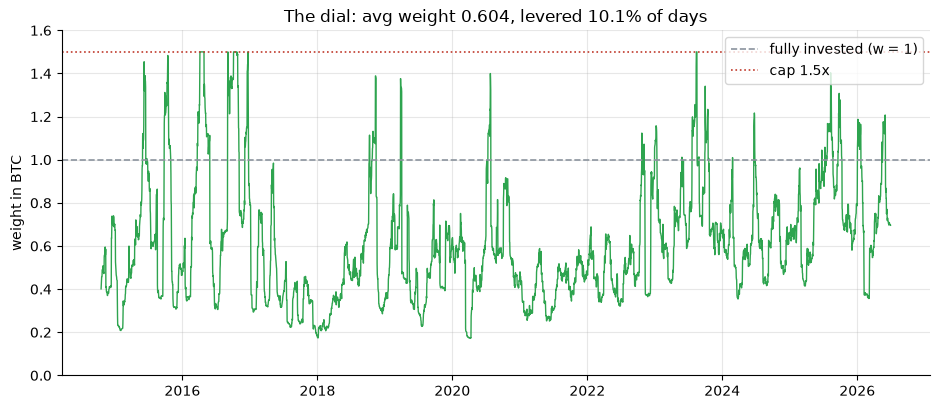

vol-targeted: CAGR  +38.12%  vol  35.54%  Sharpe +1.087  maxDD  -52.90%  wealth x43.9
buy & hold : CAGR  +53.63%  vol  66.50%  Sharpe +0.981  maxDD  -83.40%  wealth x152.6
log-growth gap -10.64%/yr  HAC t = -1.00
HAC alpha +7.18%/yr  t = +1.42  beta 0.482  appraisal +0.468


In [2]:
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    ax.plot(OV['w'].index, OV['w'], c=GREEN, lw=1.0)
    ax.axhline(1.0, ls='--', c=GREY, lw=1.2, label='fully invested (w = 1)')
    ax.axhline(1.5, ls=':', c=RED, lw=1.2, label='cap 1.5x')
    ax.set_ylabel('weight in BTC'); ax.set_ylim(0, 1.6)
    ax.set_title(f'The dial: avg weight {OV["avg_w"]:.3f}, levered {OV["share_levered"]*100:.1f}% of days')
    ax.legend(loc='upper right'); plt.tight_layout(); plt.show()
    r = st.race(RET)
    for leg, p in (('vol-targeted', r['strat']), ('buy & hold ', r['bh'])):
        print(f"{leg}: CAGR {p['cagr_pct']:+7.2f}%  vol {p['vol_ann_pct']:6.2f}%  "
              f"Sharpe {p['sharpe']:+.3f}  maxDD {p['maxdd_pct']:+7.2f}%  wealth x{p['wealth_mult']:,.1f}")
    print(f"log-growth gap {r['growth_gap_ann_pct']:+.2f}%/yr  HAC t = {r['t_growth_gap']:+.2f}")
    print(f"HAC alpha {r['alpha_ann_pct']:+.2f}%/yr  t = {r['t_alpha']:+.2f}  beta {r['beta']:.3f}  appraisal {r['appraisal']:+.3f}")
else:
    print('cache missing - frozen:', {k: R[k] for k in ('s_sharpe','b_sharpe','alpha','t_alpha','gap_ann','t_gap')})

> 💡 In plain words: the rule holds **0.6× ≈ 60%** of a full BTC position on average (levered only 10% of days), nudges the Sharpe from 0.98 to 1.09, and earns a positive but **uncertified** alpha (+7.18%/yr, t = 1.42 — below the desk's t ≥ 2 bar). Meanwhile the log-growth gap is -10.6 pp/yr against the overlay.

### 4b · The placebo — timing or just holding less?

200 shuffled-RV overlays: identical weight *distribution*, zero alignment with tomorrow's risk. If the real overlay's drawdown/alpha sit inside the shuffled cloud, the "skill" was mere exposure reduction.

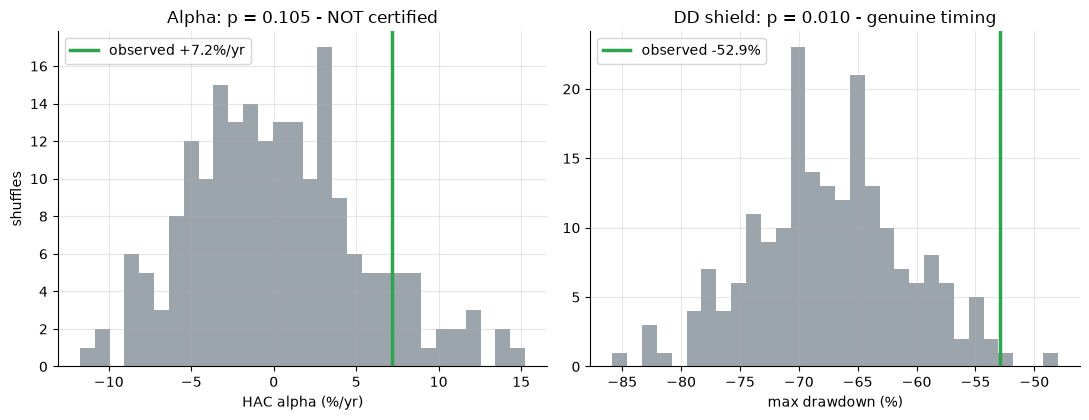

alpha: obs +7.18%/yr vs placebo mean +0.23%/yr  p=0.105
maxDD: obs -52.90% vs placebo mean -67.34%  p=0.010


In [3]:
if HAVE_REAL:
    pl = st.placebo_shuffle(RET, n_seeds=200)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
    a1.hist(pl['alpha_draws'], bins=30, color=GREY, alpha=.85)
    a1.axvline(pl['obs_alpha_ann_pct'], c=GREEN, lw=2.5,
               label=f"observed {pl['obs_alpha_ann_pct']:+.1f}%/yr")
    a1.set_xlabel('HAC alpha (%/yr)'); a1.set_ylabel('shuffles')
    a1.set_title(f"Alpha: p = {pl['p_alpha']:.3f} - NOT certified"); a1.legend()
    a2.hist(pl['dd_draws'], bins=30, color=GREY, alpha=.85)
    a2.axvline(pl['obs_maxdd_pct'], c=GREEN, lw=2.5,
               label=f"observed {pl['obs_maxdd_pct']:.1f}%")
    a2.set_xlabel('max drawdown (%)')
    a2.set_title(f"DD shield: p = {pl['p_dd']:.3f} - genuine timing"); a2.legend()
    plt.tight_layout(); plt.show()
    print(f"alpha: obs {pl['obs_alpha_ann_pct']:+.2f}%/yr vs placebo mean {pl['placebo_mean_alpha']:+.2f}%/yr  p={pl['p_alpha']:.3f}")
    print(f"maxDD: obs {pl['obs_maxdd_pct']:+.2f}% vs placebo mean {pl['placebo_mean_maxdd_pct']:+.2f}%  p={pl['p_dd']:.3f}")
else:
    print('cache missing - frozen: p_alpha %.3f  p_dd %.3f' % (R['pl_p_alpha'], R['pl_p_dd']))

> 💡 In plain words: random same-size exposure gets you a **-67%** drawdown; the timed rule gets **-52.9%**, and only **2 of 200** shuffles match it (p = 0.010) — the shield is *information*, not dilution. The alpha, though, is matched by one shuffle in ten (p = 0.105): not certifiable. This is the cleanest statement of the split verdict.

### 4c · The grid — parameter-robust where it's real

Targets 20/30/50% × windows 20/30/60d. Left: the drawdown cut (real everywhere). Right: the alpha t (certified nowhere).

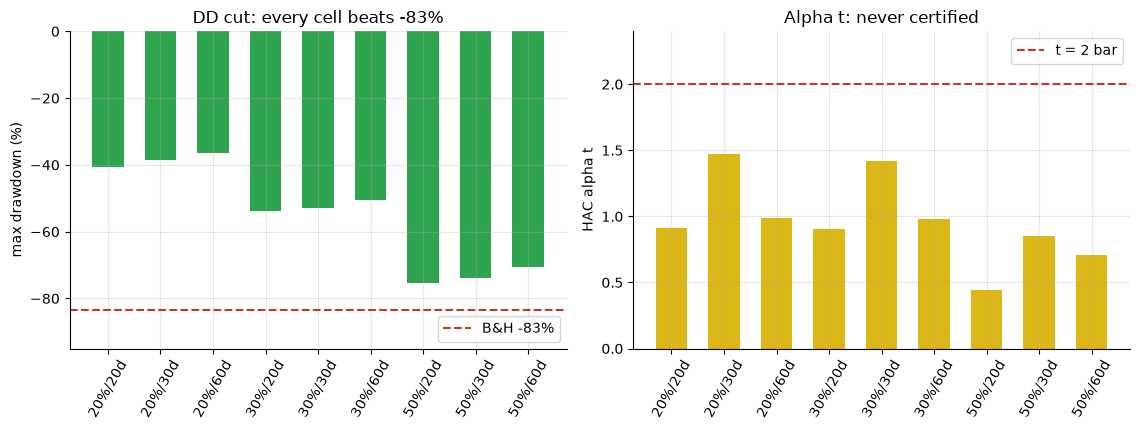

target 20% window 20d: Sharpe +1.018  maxDD  -40.56%  CAGR +24.94%  alpha t +0.91  gap t -1.66
target 20% window 30d: Sharpe +1.095  maxDD  -38.61%  CAGR +26.16%  alpha t +1.48  gap t -1.49
target 20% window 60d: Sharpe +1.035  maxDD  -36.57%  CAGR +22.95%  alpha t +0.99  gap t -1.66
target 30% window 20d: Sharpe +1.018  maxDD  -53.78%  CAGR +35.93%  alpha t +0.90  gap t -1.27
target 30% window 30d: Sharpe +1.087  maxDD  -52.90%  CAGR +38.12%  alpha t +1.42  gap t -1.00
target 30% window 60d: Sharpe +1.034  maxDD  -50.38%  CAGR +33.71%  alpha t +0.98  gap t -1.31
target 50% window 20d: Sharpe +0.971  maxDD  -75.36%  CAGR +47.57%  alpha t +0.44  gap t -0.69
target 50% window 30d: Sharpe +1.013  maxDD  -74.01%  CAGR +50.58%  alpha t +0.85  gap t -0.27
target 50% window 60d: Sharpe +1.004  maxDD  -70.47%  CAGR +48.91%  alpha t +0.71  gap t -0.47


In [4]:
rows = R['grid']
if HAVE_REAL:
    g = st.grid(RET)
    rows = [(int(x['target']*100), x['window'], x['sharpe'], x['maxdd_pct'],
             x['cagr_pct'], x['t_alpha'], x['t_growth_gap']) for x in g]
labels = [f"{r[0]}%/{r[1]}d" for r in rows]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
a1.bar(labels, [r[3] for r in rows], color=GREEN, width=.6)
a1.axhline(R['b_dd'], ls='--', c=RED, lw=1.5, label=f"B&H {R['b_dd']:.0f}%")
a1.set_ylabel('max drawdown (%)'); a1.set_ylim(-95, 0)
a1.tick_params(axis='x', rotation=60)
a1.set_title('DD cut: every cell beats -83%'); a1.legend(loc='lower right')
a2.bar(labels, [r[5] for r in rows], color=AMBER, width=.6)
a2.axhline(2, ls='--', c=RED, lw=1.5, label='t = 2 bar')
a2.set_ylabel('HAC alpha t'); a2.set_ylim(0, 2.4)
a2.tick_params(axis='x', rotation=60)
a2.set_title('Alpha t: never certified'); a2.legend(loc='upper right')
plt.tight_layout(); plt.show()
for r in rows:
    print(f'target {r[0]:>2}% window {r[1]:>2}d: Sharpe {r[2]:+.3f}  maxDD {r[3]:+7.2f}%  '
          f'CAGR {r[4]:+6.2f}%  alpha t {r[5]:+.2f}  gap t {r[6]:+.2f}')

> 💡 In plain words: the *risk* result is not a parameter fluke — all nine cells cut the −83.4% drawdown, smoothly scaled by the target (20% target → −37…−41%, 50% → −70…−75%). The *return* result is a fluke-shaped nothing — alpha t between 0.44 and 1.48, growth-gap t negative in every cell. There is no knob setting with both halves of the promise.

### 4d · Costs & whipsaw — cheap to run, and it doesn't matter

Turnover is 6.97× NAV/yr; the levered fraction (w > 1 on 10.1% of days) pays a retail borrow spread.

In [5]:
rows = R['costs']
if HAVE_REAL:
    rows = []
    for cb, bs in ((0.0,0.0),(5.0,0.0),(10.0,0.02),(20.0,0.05)):
        rc = st.race(RET, cost_bps=cb, borrow_spread_ann=bs)
        rows.append((cb, bs*100, rc['strat']['sharpe'], rc['strat']['cagr_pct'],
                     rc['strat']['maxdd_pct'], rc['alpha_ann_pct'], rc['t_alpha']))
print(f"{'cost':>6} {'borrow':>7} | {'Sharpe':>7} {'CAGR':>8} {'maxDD':>8} {'alpha':>8} {'t':>6}")
for cb, bs, sh, cg, dd, al, ta in rows:
    print(f'{cb:>4.0f}bp {bs:>6.0f}% | {sh:>7.3f} {cg:>+7.2f}% {dd:>+7.2f}% {al:>+7.2f}% {ta:>+6.2f}')

  cost  borrow |  Sharpe     CAGR    maxDD    alpha      t
   0bp      0% |   1.087  +38.12%  -52.90%   +7.18%  +1.42
   5bp      0% |   1.077  +37.64%  -53.04%   +6.83%  +1.35
  10bp      2% |   1.066  +37.10%  -53.19%   +6.44%  +1.27
  20bp      5% |   1.045  +36.07%  -53.49%   +5.68%  +1.13


> 💡 In plain words: even at a punitive 20 bps per trade plus 5% margin borrow, the Sharpe only drops 1.087 → 1.045 and the drawdown moves half a point. Costs are **not** the problem with this strategy; the absent certified edge is. (What fails the bar gross also fails it net — t goes 1.42 → 1.13.)

### 4e · Faithful-engine & power control — we know the truth here

Two seeded vol-clustered worlds, 20 seeds each: a **risk-priced null** (μ_t ∝ σ_t², vol timing must earn nothing) and a **planted leverage-effect world** (mean falls as variance rises — the Moreira-Muir disconnect; the overlay MUST light up).

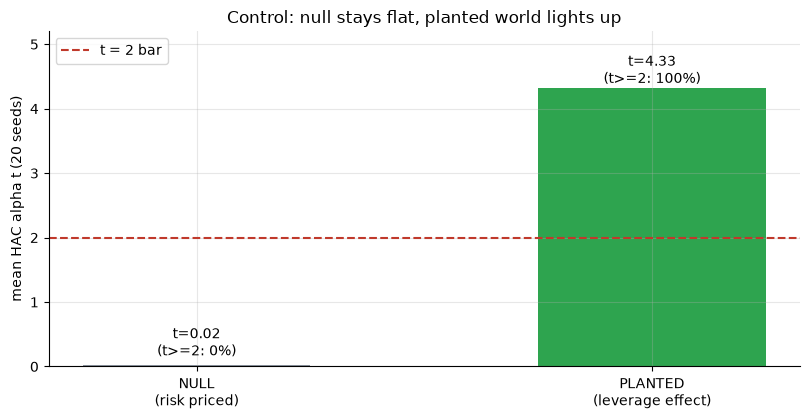

null    : mean alpha   +0.21%/yr  mean t +0.02 +/- 0.69  share t>=2 0%
planted : mean alpha  +27.02%/yr  mean t +4.33 +/- 0.75  share t>=2 100%


In [6]:
res = [st.synthetic_check(disconnect=dc, n_seeds=20) for dc in (0.0, 2.0)]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
labels = ['NULL\n(risk priced)', 'PLANTED\n(leverage effect)']
tvals = [r['mean_t'] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res):
    ax.annotate(f"t={r['mean_t']:.2f}\n(t>=2: {r['share_t_ge_2']*100:.0f}%)", (i, max(r['mean_t'], .1)),
                ha='center', va='bottom')
ax.set_ylabel('mean HAC alpha t (20 seeds)'); ax.set_ylim(0, 5.2)
ax.set_title('Control: null stays flat, planted world lights up'); ax.legend()
plt.tight_layout(); plt.show()
for name, r in zip(('null', 'planted'), res):
    print(f"{name:<8}: mean alpha {r['mean_alpha_ann_pct']:+7.2f}%/yr  mean t {r['mean_t']:+.2f} "
          f"+/- {r['sd_t']:.2f}  share t>=2 {r['share_t_ge_2']*100:.0f}%")

> 💡 In plain words: when risk is fairly priced the harness reports nothing (mean t = +0.02, 0% false positives); when a genuine vol-return disconnect is planted it fires on every seed (mean t = 4.33). The machinery can bank the effect when it exists — so the real-tape t = 1.42 is the tape talking, not a blind harness. *(A faithful-engine / power check only — never cited in support of a stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real on the heart attacks:* max DD **-52.90% vs -83.40%**, robust in all nine grid cells, and certified as timing by the shuffled-signal placebo (**p = 0.010**, 200 seeds; placebo mean DD -67.34%). *Weak on the ride:* HAC alpha **+7.18%/yr at t = 1.42** (placebo p = 0.105), grid alpha t 0.44–1.48 — never above the bar. Single-asset survivor tape, named.
- **Tradability `FRAGILE`** — turnover 6.97× NAV/yr, unlimited capacity, retail-accessible, and robust to 20 bps + 5% borrow (Sharpe 1.045). But the certified deliverable is risk control — you pay a realized **15.51 pp/yr** CAGR give-up for it, and the uncertified Sharpe edge rests on one 11.8-year tape. Not INVESTABLE as an *edge*; deployable as a *shield*.
- **Same ride? `BUSTED`** — ×43.9 vs ×152.6 terminal wealth (28.8% kept); the growth gap (-10.64 log-pp/yr) is statistically noise-compatible (HAC t = -1.00) but the realized arithmetic is decisive: this is a different, smaller ride.

## 6 · Going further

- **Why equities and not BTC?** Moreira-Muir alpha feeds on a *vol-return disconnect*. On this BTC tape the disconnect exists but is too noisy to certify in 11.8 years — the point estimate is positive (+7%/yr), the error bars are crypto-sized. Compare [591-vol-managed-portfolio](../../591-vol-managed-portfolio/README.md), where 33 years of SPY/QQQ gets the same recipe over the bar (barely).
- **Risk overlay vs return engine.** The DD placebo (p = 0.010) is the study's most durable fact: trailing vol *forecasts* BTC crash risk. That is bankable as position sizing even if the alpha never certifies.
- **The sizing-vs-timing frontier.** [210-crypto-trend](../../210-crypto-trend/README.md) achieves −70% DD with a binary SMA rule; this overlay gets −53% with continuous sizing at similar cost. Combining the two signals (trend for direction, vol for size) is the obvious next study.

*The reproducible core is offline and deterministic; the signal is trailing 30d realized vol with one day of lag. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*